In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import scipy
import matplotlib.pylab as pylab
import matplotlib.axes as axes
from scipy.optimize import curve_fit
import ROOT

params = {'legend.fontsize': 'large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'large',
         'ytick.labelsize':'large',
         'xtick.direction':'in',
         'ytick.direction':'in',
         'xtick.bottom':'True',
         'xtick.top':'True',
         'ytick.right':'True',
         'xtick.major.width':1.5,
         'ytick.major.width':1.5,
         'xtick.major.size':6,
         'ytick.major.size':6}
pylab.rcParams.update(params)

Linestyle = 'solid'
Linestyle2 = 'dashed'
Linestyle3 = 'dotted'
Linestyle4 = (0,(5,10))
Linestyle5 = "None"

Welcome to JupyROOT 6.30/04


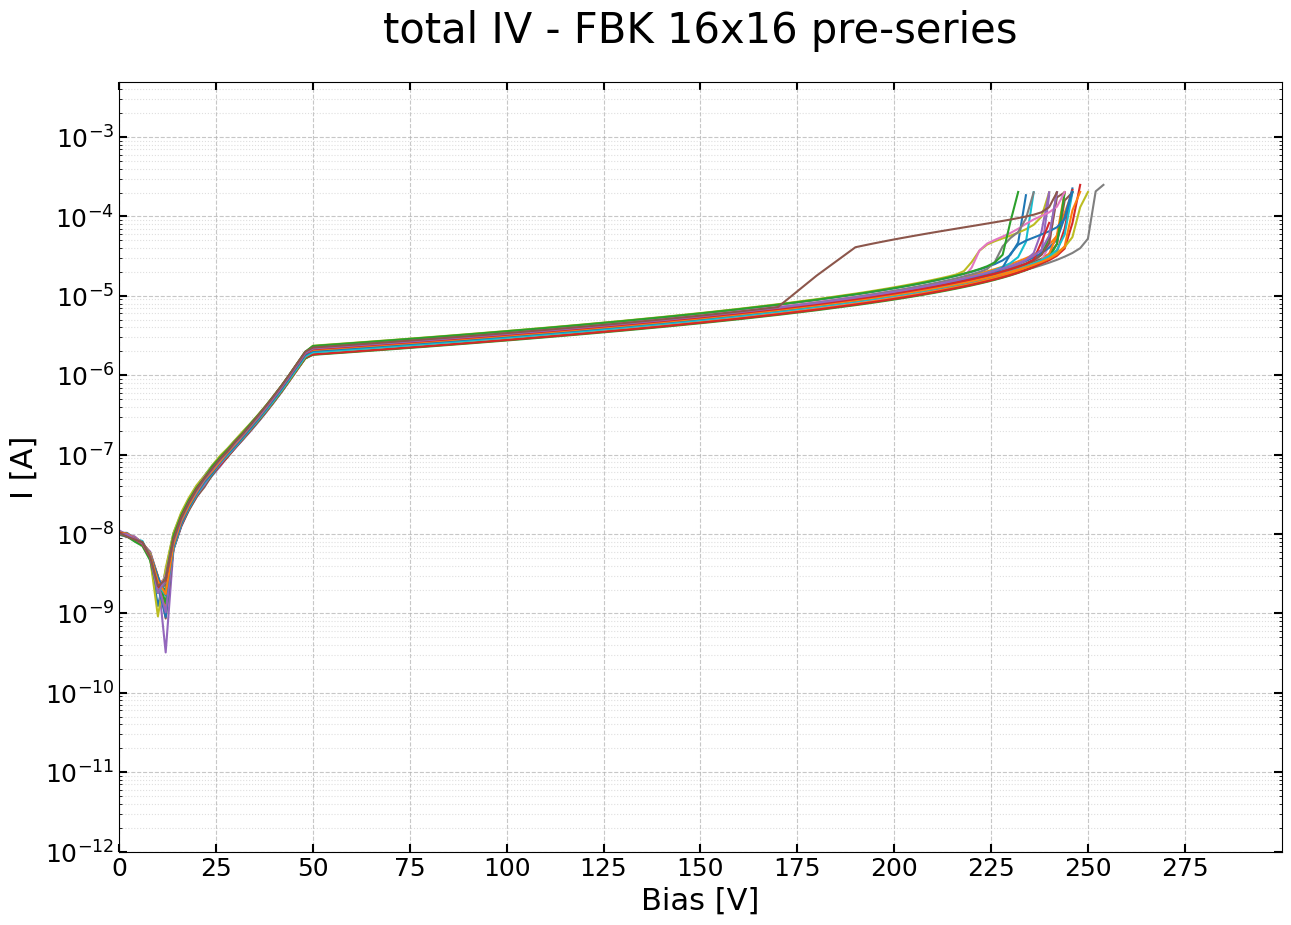

In [12]:
import ROOT
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker # <--- Importante per i locators

def plot_iv_curves_on_same_plot(root_file, tree_name="Tree"):
    """
    Plots all IV curves from a ROOT tree on the same plot.

    Args:
        root_file: Path to the ROOT file.
        tree_name: Name of the tree in the ROOT file.

    Returns:
        None (displays the plot).
    """

    file_qa = ROOT.TFile.Open(root_file)
    tree_qa = file_qa.Get(tree_name)

    plt.figure(figsize=(15, 10))  # Adjust figure size as needed

    for i, event in enumerate(tree_qa):
        #if event.wafer==15 and event.sensor==12:
        #if event.wafer==15 and event.column==4 and event.row==2:
        #if event.wafer==14 and (event.sensor==2 or event.sensor==3):
        if event.wafer==16 and event.row>3:
            ipad_values = np.array(event.IBACK, dtype=float)
            v_values = np.array(event.V, dtype=float)
            #v_values = v_values[:len(ipad_values)]
            plt.plot(v_values, ipad_values, label=f"Wafer: {event.wafer} - Sensor: {event.sensor}") 
    
    
            
    plt.xlabel("Bias [V]", fontsize=22)
    plt.ylabel("I [A]", fontsize=22)
    plt.yscale('log')
    
    #y_ticks_major = np.arange(0, 76, 5)
    x_ticks_major = np.arange(0, 300, 25)
    
    #plt.yticks(y_ticks_major)
    plt.xticks(x_ticks_major)
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    
    plt.xlim(0, 300) 
    plt.ylim(1e-12, 5*1e-3) 
    
    # --- CONFIGURAZIONE MINOR TICKS LOG ---
    # Usiamo plt.gca() per accedere alle proprietà dell'asse corrente
    ax = plt.gca()
    # Forza la comparsa di un tick per ogni decade (base 10)
    ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=15))
    # Imposta i minor ticks per la scala logaritmica (i multipli da 2 a 9)
    ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=(.2, .3, .4, .5, .6, .7, .8, .9), numticks=12))
    # Rende i minor ticks invisibili come testo (solo segni grafici)
    ax.yaxis.set_minor_formatter(ticker.NullFormatter())
    
    # Griglie: differenziamo major e minor per leggibilità
    plt.grid(True, which="major", axis='both', linestyle='--', alpha=0.7)
    plt.grid(True, which="minor", axis='y', linestyle=':', alpha=0.4)
    
    #plt.grid(axis='x', linestyle='--', alpha=0.7)
    #plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.title("total IV - FBK 16x16 pre-series", fontsize=30, y=1.04)
    #plt.title("total IV - HPK 16x16 pre-series ( W49 )", fontsize=30, y=1.04)
    #plt.legend(fontsize=10)
    plt.grid(True)
    plt.show()

    file_qa.Close()

# Example usage:
root_file = "/Users/icosivi/Desktop/PRE-SERIE/FBK/PRE-SERIE_FBK_Vendor_16x16_IV.root" 
plot_iv_curves_on_same_plot(root_file)

In [ ]:
import ROOT
import matplotlib.pyplot as plt
import numpy as np

def plot_iv_curves_on_same_plot(root_file, tree_name="Tree"):
    """
    Plots all IV curves from a ROOT tree on the same plot.

    Args:
        root_file: Path to the ROOT file.
        tree_name: Name of the tree in the ROOT file.

    Returns:
        None (displays the plot).
    """

    file_qa = ROOT.TFile.Open(root_file)
    tree_qa = file_qa.Get(tree_name)

    plt.figure(figsize=(15, 10))  # Adjust figure size as needed

    for i, event in enumerate(tree_qa):
        if event.wafer==1 or event.wafer==2:
            ipad_values = np.array(event.IBACK, dtype=float)
            v_values = np.array(event.V, dtype=float)
            v_values = v_values[:len(ipad_values)]
            plt.plot(v_values, ipad_values, label=f"Event {i+1}") 
    
    
            
    plt.xlabel("V Bias [V]", fontsize=18)
    plt.ylabel("I [A]", fontsize=18)
    plt.yscale('log')
    plt.ylim(10E-10,10E-4)
    plt.xlim(-20,305)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.title("IV curve - LFoundry 16x16 W2 (ETL site)", fontsize=22, y=1.04)
    #plt.legend(fontsize=10)  # Adjust legend font size
    plt.grid(True)
    plt.show()

    file_qa.Close()

# Example usage:
root_file = "../../root_files/LFoundry_16x16_probecard.root" 
plot_iv_curves_on_same_plot(root_file)

In [ ]:
import ROOT
import matplotlib.pyplot as plt
import numpy as np

tree_name="Tree"

root_file = "/Users/icosivi/Desktop/LF_PRR/plot_UFSDLF/FBK-LF_Irr10e14/LFoundry_16x16_Irr10e14.root" 
root_fileb = "/Users/icosivi/Desktop/LF_PRR/plot_UFSDLF/FBK-LF_Irr15e14/LFoundry_16x16_Irr15e14.root" 

file_qab = ROOT.TFile.Open(root_fileb)
tree_qab = file_qab.Get(tree_name)
    
file_qa = ROOT.TFile.Open(root_file)
tree_qa = file_qa.Get(tree_name)

plt.figure(figsize=(15, 10))  # Adjust figure size as needed

for i, event in enumerate(tree_qa):
        if event.wafer==1 or event.wafer==2:
            ipad_values = np.array(event.IBACK, dtype=float)
            v_values = np.array(event.V, dtype=float)
            v_values = v_values[:len(ipad_values)]
            print(ipad_values[-1])
            print(v_values[-1])
            plt.plot(v_values, ipad_values, label=f"Event {i+1}") 
    
for i, event in enumerate(tree_qab):
        if event.wafer==1 or event.wafer==2:
            ipad_values = np.array(event.IBACK, dtype=float)
            v_values = np.array(event.V, dtype=float)
            v_values = v_values[:len(ipad_values)]
            print(ipad_values[-1])
            print(v_values[-1])
            plt.plot(v_values, ipad_values, label=f"Event {i+1}")
    
    
            
plt.xlabel("V Bias [V]", fontsize=18)
plt.ylabel("I [A]", fontsize=18)
plt.yscale('log')
#plt.ylim(10E-10,10E-4)
#plt.xlim(-20,305)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title(r"IV curve - LFoundry 16x16 W1 irradiated 1E15 $n_{eq}/cm^{2}$  (ETL site)", fontsize=22, y=1.04)
#plt.legend(fontsize=10)  # Adjust legend font size
plt.grid(True)
plt.show()

file_qa.Close()
file_qab.Close()

In [ ]:
import ROOT
import matplotlib.pyplot as plt
import numpy as np

def plot_iv_curves_on_same_plot(root_file, tree_name="Tree"):
    """
    Plots all IV curves from a ROOT tree on the same plot.

    Args:
        root_file: Path to the ROOT file.
        tree_name: Name of the tree in the ROOT file.

    Returns:
        None (displays the plot).
    """

    file_qab = ROOT.TFile.Open(root_fileb)
    tree_qab = file_qa.Get(tree_name)
    
    file_qa = ROOT.TFile.Open(root_file)
    tree_qa = file_qa.Get(tree_name)

    plt.figure(figsize=(15, 10))  # Adjust figure size as needed

    for i, event in enumerate(tree_qa):
        if event.wafer==1 or event.wafer==2:
            ipad_values = np.array(event.IBACK, dtype=float)
            v_values = np.array(event.V, dtype=float)
            v_values = v_values[:len(ipad_values)]
            print(ipad_values[-1])
            print(v_values[-1])
            plt.plot(v_values, ipad_values, label=f"Event {i+1}") 
    
    for i, event in enumerate(tree_qab):
        if event.wafer==1 or event.wafer==2:
            ipad_values = np.array(event.IBACK, dtype=float)
            v_values = np.array(event.V, dtype=float)
            v_values = v_values[:len(ipad_values)]
            print(ipad_values[-1])
            print(v_values[-1])
            plt.plot(v_values, ipad_values, label=f"Event {i+1}")
    
    
            
    plt.xlabel("V Bias [V]", fontsize=18)
    plt.ylabel("I [A]", fontsize=18)
    plt.yscale('log')
    #plt.ylim(10E-10,10E-4)
    #plt.xlim(-20,305)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.title(r"IV curve - LFoundry 16x16 W1 irradiated 1E15 $n_{eq}/cm^{2}$  (ETL site)", fontsize=22, y=1.04)
    #plt.legend(fontsize=10)  # Adjust legend font size
    plt.grid(True)
    plt.show()

    file_qa.Close()

# Example usage:
root_file = "/Users/icosivi/Desktop/LF_PRR/plot_UFSDLF/FBK-LF_Irr10e14/LFoundry_16x16_Irr10e14.root" 
root_fileb = "/Users/icosivi/Desktop/LF_PRR/plot_UFSDLF/FBK-LF_Irr15e14/LFoundry_16x16_Irr15e14.root" 
plot_iv_curves_on_same_plot(root_file)

In [ ]:
import ROOT
import matplotlib.pyplot as plt
import numpy as np

def plot_iv_curves_on_same_plot(root_file, tree_name="Tree"):
    """
    Plots all IV curves from a ROOT tree on the same plot.

    Args:
        root_file: Path to the ROOT file.
        tree_name: Name of the tree in the ROOT file.

    Returns:
        None (displays the plot).
    """

    file_qa = ROOT.TFile.Open(root_file)
    tree_qa = file_qa.Get(tree_name)

    plt.figure(figsize=(15, 10))  # Adjust figure size as needed

    for i, event in enumerate(tree_qa):
        if event.wafer==1 or event.wafer==2:
            ipad_values = np.array(event.I_PAD1, dtype=float)
            v_values = np.array(event.V, dtype=float)
            v_values = v_values[:len(ipad_values)]
            plt.plot(v_values, ipad_values, label=f"Event {i+1}") 
    
    for i, event in enumerate(tree_qa):
        if event.wafer==1 or event.wafer==2:
            ipad_values = np.array(event.I_PAD2, dtype=float)
            v_values = np.array(event.V, dtype=float)
            v_values = v_values[:len(ipad_values)]
            plt.plot(v_values, ipad_values, label=f"Event {i+1}") 
            
    for i, event in enumerate(tree_qa):
        if event.wafer==1 or event.wafer==2:
            ipad_values = np.array(event.I_PAD3, dtype=float)
            v_values = np.array(event.V, dtype=float)
            v_values = v_values[:len(ipad_values)]
            plt.plot(v_values, ipad_values, label=f"Event {i+1}") 
    
    
            
    plt.xlabel("V Bias [V]", fontsize=18)
    plt.ylabel("I [A]", fontsize=18)
    plt.yscale('log')
    #plt.ylim(10E-10,10E-4)
    #plt.xlim(-20,305)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.title("IV curve - LFoundry 16x16 W2 (ETL site) - Pad Current", fontsize=22, y=1.04)
    #plt.legend(fontsize=10)  # Adjust legend font size
    plt.grid(True)
    plt.show()

    file_qa.Close()

# Example usage:
root_file = "../../root_files/LFoundry_16x16_probe_card_IPAD.root" 
plot_iv_curves_on_same_plot(root_file)

In [ ]:
plt.figure( figsize = (12,8))
plt.axes

#data1 = pd.read_csv('cv.txt',nrows=128)
data1 = pd.read_csv('cv_fixed.txt',nrows=128)
data2 = pd.read_csv('cv_der.txt',nrows=128)
#data2 = pd.read_csv('cv_fixed.txt',nrows=128)

plt.xlim(22.3,22.9)
plt.ylim(22.5,23.5)
#plt.xlabel('VGL from the intercept method')
plt.xlabel('VGL from the constant thr method (50pF)')
#plt.xlabel('VGL from the derivative method')
plt.ylabel('VGL from the derivative')
plt.plot(data1, data2,'bo')

In [ ]:
plt.figure( figsize = (12,8))
plt.axes

#sensor = '16x16_W2_5-4_col6'
#sensor = '16x16_W2_5-5_col3'
#sensor = '16x16_W7_4-5_col9'
sensor = '16x16_W16_5-5_col3'

# Load data
data1 = pd.read_csv('data/bumps_elastomer/'+str(sensor)+'_pad1-4.txt',delimiter='\t', nrows=152,skiprows=113)
data2 = pd.read_csv('data/bumps_elastomer/'+str(sensor)+'_pad5-8.txt',delimiter='\t', nrows=152,skiprows=113)
data3 = pd.read_csv('data/bumps_elastomer/'+str(sensor)+'_pad9-12.txt',delimiter='\t', nrows=152,skiprows=113)
data4 = pd.read_csv('data/bumps_elastomer/'+str(sensor)+'_pad13-16.txt',delimiter='\t', nrows=152,skiprows=113)

# Plot
x = data1['V6']*(-1)

y1 = data1['I_pad1']*1E03
y2 = data1['I_pad2']*1E03
y3 = data1['I_pad3']*1E03
y4 = data1['I_pad4']*1E03
yback = data3['I_back']*1E03*(-1)
yGR = data3['I_GR']*1E03

y5 = data2['I_pad1']*1E03
y6 = data2['I_pad2']*1E03
y7 = data2['I_pad3']*1E03
y8 = data2['I_pad4']*1E03

y9 = data3['I_pad1']*1E03
y10 = data3['I_pad2']*1E03
y11 = data3['I_pad3']*1E03
y12 = data3['I_pad4']*1E03

y13 = data4['I_pad1']*1E03
y14 = data4['I_pad2']*1E03
y15 = data4['I_pad3']*1E03
y16 = data4['I_pad4']*1E03


plt.plot(x, y1,label="Pad 1")
plt.plot(x, y2,label="Pad 2")
plt.plot(x, y3,label="Pad 3")
plt.plot(x, y4,label="Pad 4")
plt.plot(x, y5,label="Pad 5")
plt.plot(x, y6,label="Pad 6")
plt.plot(x, y7,label="Pad 7")
plt.plot(x, y8,label="Pad 8")
plt.plot(x, y9,label="Pad 9")
plt.plot(x, y10,label="Pad 10")
plt.plot(x, y11,label="Pad 11")
plt.plot(x, y12,label="Pad 12")
plt.plot(x, y13,label="Pad 13")
plt.plot(x, y14,label="Pad 14")
plt.plot(x, y15,label="Pad 15")
plt.plot(x, y16,label="Pad 16")
plt.plot(x, yGR,label="I GR",color='b')
plt.plot(x, yback,label="I total",color='r')

plt.title('16x16 UFSD4 W16 5-5',fontsize=26)
plt.xlabel('V bias [V]')
plt.ylabel('I [mA]')
plt.yscale("log")
plt.legend(loc='lower right',ncol=2)
plt.grid(linestyle=Linestyle4)
#plt.show()
plt.savefig("/home/federico/Scrivania/16x16_bumps_W16_5-5.png")

In [ ]:
plt.figure( figsize = (12,8))
plt.axes


# Load data
data1 = pd.read_csv('/Users/icosivi/Desktop/download/Irr1.5E15/IV FBK-LF_W1_3-6_1.5E15 [(12) ; 2025-07-09 3_49_38 PM].txt',delimiter='\t', nrows=305,skiprows=115)
data2 = pd.read_csv('/Users/icosivi/Desktop/download/Irr1.5E15/IV FBK-LF_W1_4-7_1.5E15 [(10) ; 2025-07-09 3_00_04 PM].txt',delimiter='\t', nrows=305,skiprows=115)
data3 = pd.read_csv('/Users/icosivi/Desktop/download/Irr1.5E15/IV FBK-LF_W1_5-7_1.5E15 [(13) ; 2025-07-09 4_10_37 PM].txt',delimiter='\t', nrows=305,skiprows=115)
data4 = pd.read_csv('/Users/icosivi/Desktop/download/Irr1.5E15/IV FBK-LF_W1_6-7_1.5E15 [(11) ; 2025-07-09 3_29_04 PM].txt',delimiter='\t', nrows=305,skiprows=115)

data5 = pd.read_csv('/Users/icosivi/Desktop/download/Irr1E15/IV FBK-LF_W1_2-4_1E15 [(6) ; 2025-07-09 1_08_22 PM].txt',delimiter='\t', nrows=307,skiprows=115)
data6 = pd.read_csv('/Users/icosivi/Desktop/download/Irr1E15/IV FBK-LF_W1_3-3_1E15 [(8) ; 2025-07-09 2_18_39 PM].txt',delimiter='\t', nrows=307,skiprows=115)
data7 = pd.read_csv('/Users/icosivi/Desktop/download/Irr1E15/IV FBK-LF_W1_5-3_1E15 [(7) ; 2025-07-09 1_55_00 PM].txt',delimiter='\t', nrows=307,skiprows=115)
data8 = pd.read_csv('/Users/icosivi/Desktop/download/Irr1E15/IV FBK-LF_W1_6-5_1E15 [(9) ; 2025-07-09 2_39_18 PM].txt',delimiter='\t', nrows=307,skiprows=115)

# Plot
x1 = data1['V4']*(-1)
x2 = data2['V4']*(-1)
x3 = data3['V4']*(-1)
x4 = data4['V4']*(-1)

x5 = data5['V4']*(-1)
x6 = data6['V4']*(-1)
x7 = data7['V4']*(-1)
x8 = data8['V4']*(-1)

yback1 = data1['I_back']*(-1)
yback2 = data2['I_back']*(-1)
yback3 = data3['I_back']*(-1)
yback4 = data4['I_back']*(-1)

yback5 = data5['I_back']*(-1)
yback6 = data6['I_back']*(-1)
yback7 = data7['I_back']*(-1)
yback8 = data8['I_back']*(-1)

#plt.plot(x1, yback1)
#plt.plot(x2, yback2)
#plt.plot(x3, yback3)
#plt.plot(x4, yback4)

plt.plot(x5, yback5)
plt.plot(x6, yback6)
plt.plot(x7, yback7)
plt.plot(x8, yback8)

#plt.title('IV curve - LFoundry 16x16 W1 irradiated',fontsize=26)
plt.title(r"IV curve - LFoundry 16x16 W1 irradiated 1E15 $n_{eq}/cm^{2}$  (ETL site)", fontsize=22, y=1.04)
plt.xlabel('V Bias [V]', fontsize=18)
plt.ylabel('I [A]', fontsize=18)
plt.yscale("log")
#plt.legend(loc='lower right')
plt.grid(linestyle=Linestyle4)
#plt.show()
#plt.savefig("/home/federico/Scrivania/16x16_bumps_W7_4-5_single-pad.png")

In [ ]:
plt.figure( figsize = (12,8))
plt.axes


# Load data
data1 = pd.read_csv('/home/federico/Scrivania/cernbox/MTD/QAQC/elastomero/HPKData/HPK2_W42_Matrix5x5/SE3-IP4_P1.txt',delimiter='\t', nrows=125,skiprows=116)
data2 = pd.read_csv('/home/federico/Scrivania/cernbox/MTD/QAQC/elastomero/HPKData/HPK2_W42_Matrix5x5/SE3-IP4_P2.txt',delimiter='\t', nrows=125,skiprows=116)
data3 = pd.read_csv('/home/federico/Scrivania/cernbox/MTD/QAQC/elastomero/HPKData/HPK2_W42_Matrix5x5/SE3-IP4_P3.txt',delimiter='\t', nrows=125,skiprows=116)
data4 = pd.read_csv('/home/federico/Scrivania/cernbox/MTD/QAQC/elastomero/HPKData/HPK2_W42_Matrix5x5/SE3-IP4_P4.txt',delimiter='\t', nrows=125,skiprows=116)


# Plot
x1 = data1['V3']*(-1)
x2 = data2['V3']*(-1)
x3 = data3['V3']*(-1)
x4 = data4['V3']*(-1)

yback1 = data1['I3']*(-1)
yback2 = data2['I3']*(-1)
yback3 = data3['I3']*(-1)
yback4 = data4['I3']*(-1)

plt.plot(x1, yback1,label="I total")
plt.plot(x2, yback2,label="I total")
plt.plot(x3, yback3,label="I total")
plt.plot(x4, yback4,label="I total")

plt.title('5x5 HPK2 split4',fontsize=26)
plt.xlabel('V bias [V]')
plt.ylabel('I [A]')
plt.yscale("log")
plt.legend(loc='lower right')
plt.grid(linestyle=Linestyle4)
#plt.show()
#plt.savefig("/home/federico/Scrivania/16x16_bumps_W7_4-5_single-pad.png")

In [ ]:
plt.figure( figsize = (12,8))
plt.axes


# Load data
data1 = pd.read_csv('/home/federico/Scrivania/IV_W19_1-1_pad1_meas2.txt',delimiter='\t', nrows=50,skiprows=113)

# Plot
x1 = data1['V6']*(-1)
x2 = data1['V6']*(-1)

yback1 = data1['I_back']*(-1)
yback2 = data1['I_pad1']

plt.plot(x1, yback1,label="I BACK",color='r')
plt.plot(x1, yback2,label="I Pad1",color='b')

plt.title('16x16 HPK2 split 4',fontsize=26)
plt.xlabel('V bias [V]')
plt.ylabel('I [A]')
plt.yscale("log")
plt.legend(loc='lower right')
plt.grid(linestyle=Linestyle4)
#plt.show()
#plt.savefig("/home/federico/Scrivania/16x16_bumps_W7_4-5_single-pad.png")

In [ ]:
# Load data
data1 = pd.read_csv('I_V_16x16_3-4_50uA.txt',delimiter='\t', nrows=70,skiprows=113)

# Plot
xx1 = data1['V6']*(-1)
#x2 = data1['V6']*(-1)

yyback1 = data1['I_back']*(-1)
#yback2 = data1['I_pad1']

plt.figure( figsize = (12,8))
plt.axes

plt.plot(xx1, yyback1,label="I BACK",color='r')
#plt.plot(x1, yback2,label="I Pad1",color='b')

plt.yticks(np.arange(0, 65, 5))
plt.xticks(np.arange(0, 325, 25))

plt.title('16x16 UFSD4 W7 3-4',fontsize=26)
plt.xlabel('V bias [V]')
plt.ylabel('I [A]')
plt.yscale("log")
#plt.legend(loc='u right')
plt.grid(linestyle=Linestyle4)
plt.show()
#plt.savefig("/home/federico/Scrivania/16x16_bumps_W7_4-5_single-pad.png")

In [ ]:
plt.figure( figsize = (12,8))
plt.axes
vbias = [200,225,250,260,270,275,280]
q = [6.8,7.7,9.5,10.5,11.9,12.6,13.6]
plt.plot(vbias, q)
plt.title('16x16 UFSD4 W7 3-4',fontsize=26)
plt.xlabel('V bias [V]')
plt.ylabel('Q [fC]')
plt.yticks(np.arange(4, 20, 2))
plt.xticks(np.arange(200, 300, 25))
plt.xlim(190,300)
plt.ylim(4,18)
plt.grid(linestyle=Linestyle4)
plt.show()

for j,current in enumerate(yyback1):
    print( abs(yyback1[j+1]-current)/abs(xx1[j+1]-xx1[j])*(abs(xx1[j])/abs(current)) ,     xx1[j])
    

In [ ]:
plt.figure( figsize = (12,8))
plt.axes


# Load data
data1 = pd.read_csv('I_V_16x16_20uA.txt',delimiter='\t', nrows=70,skiprows=113)

# Plot
x1 = data1['V6']*(-1)
#x2 = data1['V6']*(-1)

yback1 = data1['I_back']*(-1)
#yback2 = data1['I_pad1']

plt.plot(x1, yback1,label="I BACK",color='r')
#plt.plot(x1, yback2,label="I Pad1",color='b')

#plt.yticks(np.arange(0, 65, 5))
plt.xticks(np.arange(0, 325, 25))

plt.title('16x16 HPK2 split4',fontsize=26)
plt.xlabel('V bias [V]')
plt.ylabel('I [A]')
#plt.yscale("log")
#plt.legend(loc='u right')
plt.grid(linestyle=Linestyle4)
#plt.show()
plt.savefig("/Users/icosivi/Desktop/16x16_20uA.png")

In [ ]:
for j,current in enumerate(yback1):
    print( abs(yback1[j+1]-current)/abs(x1[j+1]-x1[j])*(abs(x1[j])/abs(current)) ,     x1[j])
    

In [ ]:
plt.figure( figsize = (12,8))
plt.axes

# Plot
k = [8,10,12,15,20]
vbd_mean = [279,282,287,295,301]

plt.plot(k, vbd_mean,'^',markersize=16)

plt.xticks(np.arange(6, 22, 2))

plt.title('16x16 UFSD4 W7 3-4',fontsize=26)
plt.xlabel('k-threshold')
plt.ylabel('Average VBD [V]')
#plt.yscale("log")
plt.grid(linestyle=Linestyle4)
#plt.show()
#plt.savefig("/Users/icosivi/Desktop/16x16_20uA.png")